## it is really hard to get a perfect A on these assignments
I will try to explain each step this time


## Part 1
load breast cancer data and scale to assist model fitting

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import pandas as pd
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
print(data.data.shape)

(569, 30)


In [19]:
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [20]:
print(data.target_names)

['malignant' 'benign']


instructor provided this code

In [3]:
values = np.linspace(-4, 3, num=20)
C_values = 10**values

fit the three models 

In [4]:
# 1. Lasso (L1 penalty)
lasso_lr = LogisticRegression(penalty='l1', solver='liblinear', max_iter=10000)
lasso_grid = GridSearchCV(lasso_lr, param_grid={'C': C_values}, cv=10,n_jobs=-1)
lasso_grid.fit(X_train, y_train)


,estimator,LogisticRegre...r='liblinear')
,param_grid,{'C': array([1.0000...00000000e+03])}
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [5]:
# 2. Ridge (L2 penalty)
ridge_lr = LogisticRegression(penalty='l2', max_iter=10000)
ridge_grid = GridSearchCV(ridge_lr, param_grid={'C': C_values}, cv=10,n_jobs=-1)
ridge_grid.fit(X_train, y_train)


,estimator,LogisticRegre...ax_iter=10000)
,param_grid,{'C': array([1.0000...00000000e+03])}
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [6]:
# 3. Elastic Net
# Requires penalty='elasticnet' and solver='saga'
en_lr = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=10000)
en_param_grid = {
    'C': np.logspace(-4, 3, 6),
    'l1_ratio': np.linspace(0.1, 0.9, 5) # strictly between 0 and 1
}
en_grid = GridSearchCV(en_lr, param_grid=en_param_grid, cv=10,n_jobs=-1)
en_grid.fit(X_train, y_train)

,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': array([1.0000...00000000e+03]), 'l1_ratio': array([0.1, 0....5, 0.7, 0.9])}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'elasticnet'


print C for each as well as l1 ratio for elastic net

In [7]:
print(f"Lasso Best C: {lasso_grid.best_params_['C']}")
print(f"Ridge Best C: {ridge_grid.best_params_['C']}")
print(f"Elastic Net Best Params: {en_grid.best_params_}")

Lasso Best C: 0.2069138081114788
Ridge Best C: 1.1288378916846884
Elastic Net Best Params: {'C': np.float64(0.0630957344480193), 'l1_ratio': np.float64(0.1)}


here i am finding ways to show how the models are doing. I decided to print out the coefficients and I make sure to label each coefficient its associated parameter name. i also create a dictionary that lists each model with the parameter coefficient names that equalled to zero so that we can see how each model utilized each parameter in fitting/training

In [8]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

models_to_evaluate = [
    ("Lasso", lasso_grid),
    ("Ridge", ridge_grid),
    ("Elastic Net", en_grid)
]

test_metrics = []
zeros_dict ={}
for name, grid in models_to_evaluate:
  #use best model on test set
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]
    
    
    #make into 1D array
    coefficients = best_model.coef_.ravel()
    
# Use X_train.columns to get feature names
    for feature_name, coef in zip(data.feature_names, coefficients):
        print(f"Coefficient of {feature_name} for model {name}: {coef:+.4f}")
        if coef == 0:
            if name not in zeros_dict.keys():
                zeros_dict[name] = set()
            zeros_dict[name].add(feature_name)

    test_metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "F1 Score": f1_score(y_test, y_pred),
        
    })

test_comparison = pd.DataFrame(test_metrics).sort_values(by="AUC", ascending=False)


#print(test_comparison.to_string(index=False))

Coefficient of mean radius for model Lasso: +0.0000
Coefficient of mean texture for model Lasso: -0.2149
Coefficient of mean perimeter for model Lasso: +0.0000
Coefficient of mean area for model Lasso: +0.0000
Coefficient of mean smoothness for model Lasso: +0.0000
Coefficient of mean compactness for model Lasso: +0.0000
Coefficient of mean concavity for model Lasso: +0.0000
Coefficient of mean concave points for model Lasso: -0.3667
Coefficient of mean symmetry for model Lasso: +0.0000
Coefficient of mean fractal dimension for model Lasso: +0.0000
Coefficient of radius error for model Lasso: -0.8915
Coefficient of texture error for model Lasso: +0.0000
Coefficient of perimeter error for model Lasso: +0.0000
Coefficient of area error for model Lasso: +0.0000
Coefficient of smoothness error for model Lasso: +0.0000
Coefficient of compactness error for model Lasso: +0.0000
Coefficient of concavity error for model Lasso: +0.0000
Coefficient of concave points error for model Lasso: +0.0000

below is where i show the accuracy, AUC, and f1 for each model

In [9]:
print(test_comparison.to_string(index=False))


      Model  Accuracy      AUC  F1 Score
      Lasso  0.964912 0.996693  0.971831
Elastic Net  0.964912 0.995701  0.972603
      Ridge  0.982456 0.995370  0.986111


here is my "zeros_dict" which has all of the coefficients equal to zero for each model. ridge does not abandon any coefficient and leave them at zero; this is correct behavior for the l2 regularization concept that ridge follows.
we can see above this block of text that ridge actually performs the best, and this is surprising to me because I thought the hybrid elastic net was going to do the best.

In [10]:
print("This is every coefficient per model that is equal to zero")
for key, values in zeros_dict.items():
    for val in values:
        print(f"Key: {key:12s} | Value: {val}")

This is every coefficient per model that is equal to zero
Key: Lasso        | Value: mean area
Key: Lasso        | Value: mean perimeter
Key: Lasso        | Value: mean concavity
Key: Lasso        | Value: worst concavity
Key: Lasso        | Value: worst fractal dimension
Key: Lasso        | Value: mean smoothness
Key: Lasso        | Value: mean compactness
Key: Lasso        | Value: worst compactness
Key: Lasso        | Value: mean fractal dimension
Key: Lasso        | Value: perimeter error
Key: Lasso        | Value: concavity error
Key: Lasso        | Value: smoothness error
Key: Lasso        | Value: area error
Key: Lasso        | Value: symmetry error
Key: Lasso        | Value: mean radius
Key: Lasso        | Value: worst perimeter
Key: Lasso        | Value: texture error
Key: Lasso        | Value: concave points error
Key: Lasso        | Value: compactness error
Key: Lasso        | Value: mean symmetry
Key: Elastic Net  | Value: smoothness error
Key: Elastic Net  | Value: texture

## part 2 SVCs 
in the earlier week's assignment you asked me to not copy and paste a bunch of code so i am worried i am doing this again. this is pretty readable and i like the way i can modify everything without having to go back to a single function at the top of the notebook


In [11]:
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import GridSearchCV
#recycles old scaled training data
# 1. LinearSVC - Tuning C
linearsvc_param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
linearsvc_grid = GridSearchCV(LinearSVC(max_iter=10000, dual=False), linearsvc_param_grid, cv=5, scoring='accuracy',n_jobs=-1)
linearsvc_grid.fit(X_train, y_train)

,estimator,LinearSVC(dua...ax_iter=10000)
,param_grid,"{'C': [0.001, 0.01, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [12]:

# 2. SVC Polynomial - Tuning C and degree
poly_param_grid = {'C': [0.1, 1, 10, 100], 'degree': [2, 3, 4]}
poly_svc_grid = GridSearchCV(SVC(kernel='poly'), poly_param_grid, cv=5, scoring='accuracy',n_jobs=-1)
poly_svc_grid.fit(X_train, y_train)

,estimator,SVC(kernel='poly')
,param_grid,"{'C': [0.1, 1, ...], 'degree': [2, 3, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [13]:


# 3. SVC RBF - Tuning C and gamma
rbf_param_grid = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto',0.001, 0.01, 0.1, 1]}
rbf_svc_grid = GridSearchCV(SVC(kernel='rbf'), rbf_param_grid, cv=5, scoring='accuracy',n_jobs=-1)
rbf_svc_grid.fit(X_train, y_train)


,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


exercise fitted models using the test set and find CV scores

In [14]:

svm_models = [
    ("LinearSVC", linearsvc_grid),
    ("SVC Poly", poly_svc_grid),
    ("SVC RBF", rbf_svc_grid)
]

svm_results = []

for name, grid in svm_models:
    #use best model on test set
    best_model = grid.best_estimator_
    
    # Predict and calculate scores
    y_pred = best_model.predict(X_test)
    # Use decision_function for AUC since LinearSVC doesn't have predict_proba
    y_scores = best_model.decision_function(X_test)
    
    svm_results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Best CV Score": grid.best_score_,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test AUC": roc_auc_score(y_test, y_scores),
        "Test F1": f1_score(y_test, y_pred)
    })


In [15]:
svm_comparison = pd.DataFrame(svm_results)



In [16]:
print(svm_comparison.to_string(index=False))

    Model              Best Params  Best CV Score  Test Accuracy  Test AUC  Test F1
LinearSVC              {'C': 0.01}       0.982418       0.982456  0.995701 0.986111
 SVC Poly  {'C': 100, 'degree': 3}       0.969231       0.973684  0.992725 0.979310
  SVC RBF {'C': 10, 'gamma': 0.01}       0.980220       0.982456  0.997685 0.986111


## part 3
i reload breast cancer in part 3 so i can have an easier time copying your code.
https://courses.maine.edu/content/enforced/479012-2710.UMS06-C.0438.1/pipe_cv.html?ou=479012


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
knn = KNeighborsClassifier()
param_grid = {'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 10, 15, 20, 30, 50]}
model = Pipeline([('scaler', StandardScaler()), ('knn', knn)])
grid_search = GridSearchCV(model, param_grid= param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
#set best parameters for fitting
best_model = grid_search.best_estimator_
#i use your shorthand code from the example
best_model.fit(X_train, y_train)
best_model.score(X_test, y_test)
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
print("Best n_neighbors:", grid_search.best_params_['knn__n_neighbors'])
print("Best CV score:", grid_search.best_score_)

print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("AUC on test set:", roc_auc_score(y_test, y_pred_proba))
print("F1 score on test set:", f1_score(y_test, y_pred))

Best n_neighbors: 7
Best CV score: 0.9601367989056089
Accuracy on test set: 0.951048951048951
AUC on test set: 0.989308176100629
F1 score on test set: 0.9621621621621622


Best n_neighbors happens to be 7, which is considered small and high-variance and can lead to overfitting in some models. However, the optimal value of n_neighbors depends on the specific dataset and the problem at hand. In this case, the model seems to be performing well, so the current value of n_neighbors is sufficient. 

## part 4 trying my own data set


In [39]:
obesity = pd.read_csv("../data/ObesityDataSet.csv")
obesity.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


i am basically going to recreate what i just did in part 3
I get to add more preprocessing steps. for our y column, if the person is not insufficient weight or normal weight we will flag our target as true.
add get_dummies to avoid crazy extra preprocessing steps. and so i can move on with my life and start project1 by Sunday

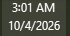

In [47]:
import pandas as pd
X = obesity.drop('NObeyesdad', axis=1)
y = obesity[['NObeyesdad']]
y['NObeyesdad'] = obesity['NObeyesdad'].apply(lambda x: 0 if x == 'Insufficient_Weight' or x == 'Normal_Weight' else 1)
X =pd.get_dummies(X,drop_first=True)
X.head()

C:\Users\owner\AppData\Local\Temp\ipykernel_46604\1937060390.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['NObeyesdad'] = obesity['NObeyesdad'].apply(lambda x: 0 if x == 'Insufficient_Weight' or x == 'Normal_Weight' else 1)


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,False,True,...,False,False,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,False,True,...,False,True,True,False,True,False,False,False,True,False
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,True,True,...,False,False,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,True,False,...,False,False,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,True,False,...,False,False,False,False,True,False,False,False,True,False


In [49]:
y.head()

,NObeyesdad
0,0
1,0
2,0
3,1
4,1


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y['NObeyesdad'].values, test_size=0.2, random_state=42)
knn = KNeighborsClassifier()
param_grid = {'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 10, 15, 20, 30, 50]}
model = Pipeline([('scaler', StandardScaler()), ('knn', knn)])
# Define the KNN model
grid_search = GridSearchCV(model, param_grid= param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
#set best parameters for fitting
best_model = grid_search.best_estimator_
#i use your shorthand code from the example to set best model
best_model.fit(X_train, y_train)
best_model.score(X_test, y_test)
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
print("Best n_neighbors:", grid_search.best_params_['knn__n_neighbors'])
print("Best CV score:", grid_search.best_score_)

print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("AUC on test set:", roc_auc_score(y_test, y_pred_proba))
print("F1 score on test set:", f1_score(y_test, y_pred))

Best n_neighbors: 1
Best CV score: 0.922406194581497
Accuracy on test set: 0.9054373522458629
AUC on test set: 0.8642817449291469
F1 score on test set: 0.9358974358974359


this is interesting that n neighbors was best at 1. the data set seems rushed. maybe i could have used a better data set. i dont know exactly yet how to find out which types of data set are best for the current model. i can figure this out with some research and i want to hear what you think as well. errors can also be mitigated with more thorough preprocessing steps. overall, the low n neighbors means there is no assumptions about data shape. ai response from my query: "When $k=1$, every training point perfects its own boundary. The model makes zero assumptions about the overall shape of the data and can capture extremely complex, flexible decision boundaries." Variance (High): The predictions are hyper-sensitive to noise, outliers, and small fluctuations in the training set. If a single noisy point flips its label, the decision boundary shifts locally. -google gemini
by the way, last weeks homework you thanked me for not vibe coding. youre right that i dont vibe code, at least i dont think i do. i try to learn what i am doing. i use ai to help me write correct code and put my ideas "into words." 